In [31]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [32]:
# Load the dataset
train_data_path = 'train_catvsnoncat.h5'
test_data_path = 'test_catvsnoncat.h5'

with h5py.File(train_data_path, 'r') as train_dataset:
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:])
    train_classes = np.array(train_dataset["list_classes"][:])

with h5py.File(test_data_path, 'r') as test_dataset:
    X_test = np.array(test_dataset["test_set_x"][:])
    Y_test = np.array(test_dataset["test_set_y"][:])
    test_classes = np.array(test_dataset["list_classes"][:])

print("origin X_train shape:", X_train.shape)
print("origin Y_train shape:", Y_train.shape)
print("origin X_test shape:", X_test.shape)
print("origin Y_test shape:", Y_test.shape)

origin X_train shape: (209, 64, 64, 3)
origin Y_train shape: (209,)
origin X_test shape: (50, 64, 64, 3)
origin Y_test shape: (50,)


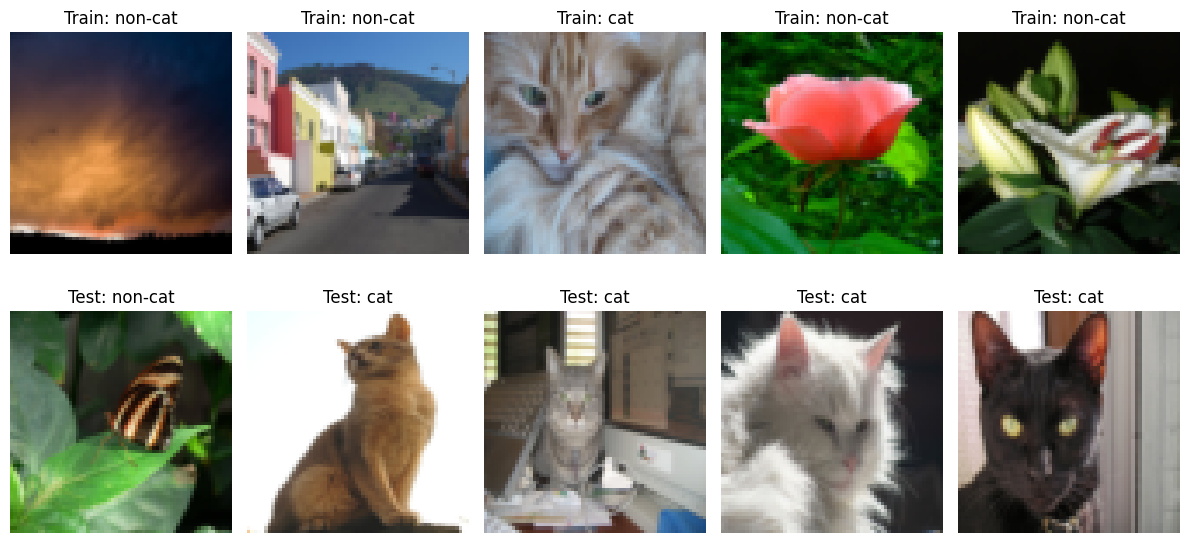

In [33]:
# Viewing some labeled images from the training set
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label = train_classes[Y_train[i]].decode("utf-8")
    plt.title(f"Train: {label}")
    plt.axis("off")

# Viewing some labeled images from the test set
for i in range(5, 10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    label = test_classes[Y_test[i]].decode("utf-8")
    plt.title(f"Test: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Input Image Resizing
The input images were **resized from (64, 64, 3) to (128, 128, 3)** because one of the supported input shapes for the **MobileNetV2** architecture is `(128, 128, 3)`. 

Resizing ensures that the data is compatible with the model’s expected input dimensions, allowing it to operate correctly and utilize its pretrained weights effectively.


In [34]:
# resizing the image from (64,64,3) to (128,128,3)
X_train = tf.image.resize(X_train, (128,128))
X_test = tf.image.resize(X_test, (128,128))

# normalizing the input image matrix
X_train = X_train/255.
X_test = X_test/255.

# changing the output labels to a column vector
Y_train = Y_train.reshape(-1, 1)
Y_test = Y_test.reshape(-1,1)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (209, 128, 128, 3)
Y_train shape: (209, 1)
X_test shape: (50, 128, 128, 3)
Y_test shape: (50, 1)


### Model Architecture and Customization

The **base model** is created from a pre-trained **MobileNetV2** network trained on the **ImageNet** dataset, which can classify 1000 different classes. In this setup, we use the model **without its top layers** (i.e., we exclude the fully connected classification layers). 

This allows us to utilize the pre-trained convolutional feature extractor for our custom task. We then **add the following layers** to adapt the model for the **cat vs. no-cat classification**:

- A **GlobalAveragePooling2D** layer to reduce the spatial dimensions of the feature maps.
- A **Fully Connected (Dense)** layer with ReLU activation to learn task-specific patterns.
- An **Output Layer** with a sigmoid activation for **binary classification** (cat vs. no-cat).

In [35]:
# 1) Load the base MobileNetV2 model (without the top/classification layers)
IMG_SHAPE = (128, 128, 3)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,           # Exclude top layers
                                               weights='imagenet')          # Use pretrained weights

# 2️) Freeze the base model layers (we're using it as a feature extractor)
base_model.trainable = False

# 3️) Add custom layers for cat vs no cat classification
global_average_layer = tfl.GlobalAveragePooling2D()
dense_layer = tfl.Dense(128, activation='relu')
dropout_layer = tfl.Dropout(0.2)                    # Optional for regularization
output_layer = tfl.Dense(1, activation='sigmoid')   # Single output neuron for binary classification

# 4️) Build the final model
model = tf.keras.Sequential([
    base_model,
    global_average_layer,
    dense_layer,
    dropout_layer,
    output_layer
])

# 5️) Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 6) Model is now ready for training
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
# train the model
model.fit(X_train, Y_train, epochs=25)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.6433 - loss: 0.6741
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9831 - loss: 0.0508
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9931 - loss: 0.0255
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 1.0000 - loss: 0.0138
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 1.0000 - loss: 0.0067
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 1.0000 - loss: 0.0068
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 12/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 1.0000 - lo

In [38]:
# test the model
model.evaluate(X_test, Y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9867 - loss: 0.0150


[0.02031806670129299, 0.9800000190734863]

### Conclusion
This approach leverages the rich, pre-trained feature representations learned from ImageNet, making it ideal for achieving robust performance even with a relatively smaller dataset.